In [1]:
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Toy simulator

Simulates a point source population on top of an isotropic background.

In [2]:
from scipy.stats import binned_statistic_2d
from astropy.convolution import convolve, Gaussian2DKernel

t_min = -1  # Coordinate boundaries
t_max = 1
n_t = 64  # Number of pixels
counts_min = 100  # Minimum and maximum counts emitted by each PS
counts_max = 100
fwhm_psf = 0.1  # FWHM of Gaussian PSF

# Pixel binning
pixel_size = (t_max - t_min) / n_t
bins = np.linspace(t_min, t_max, n_t + 1)

# PSF stuff
sigma_psf = fwhm_psf / 2 ** 1.5 * np.sqrt(np.log(2))  # Convert FWHM to standard deviation
kernel = Gaussian2DKernel(x_stddev=1.0 * sigma_psf / pixel_size)

def simulate(plot=False, poiss_fluctuate=True):
    
    mu_iso = np.random.uniform(0, 50)
    mu_ps = np.random.uniform(0, 100)
    n_ps = np.random.poisson(mu_ps)
    
    # Draw position of PSs and their counts
    z_x = np.random.uniform(t_min, t_max, size=(2, n_ps))
    z_c = np.random.uniform(counts_min, counts_max, n_ps)

    mu_iso_map = mu_iso * np.ones((n_t, n_t))

    if n_ps > 0:
        mu_signal = binned_statistic_2d(x=z_x[0], y=z_x[1], values=z_c, statistic='sum', bins=bins).statistic
        counts_binned = (mu_iso_map + convolve(mu_signal, kernel))
    else:
        counts_binned = (mu_iso_map)

    if poiss_fluctuate:
        counts_binned = np.random.poisson(counts_binned)

    if plot:
        plt.imshow(counts_binned)
    
    return mu_ps, mu_iso, counts_binned

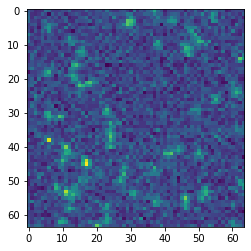

In [3]:
_, _, x = simulate(plot=True)

In [4]:
from scipy import stats

def power_spectrum(x):
    """ Power spectrum of map. Adapted from https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/
    """
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

def counts_histogram(x, counts_max=100):
    bins_hist = np.arange(counts_max)
    return np.histogram(x, bins=bins_hist)[0]

Simulate training sample

In [5]:
from tqdm.notebook import tqdm

simulations = [simulate() for _ in tqdm(range(20000))]
x = list(map(itemgetter(2), simulations))
mu_ps = list(map(itemgetter(0), simulations))
mu_iso = list(map(itemgetter(1), simulations))
x_pspec = np.array([power_spectrum(x_i) for x_i in x])
x_hist = np.array([counts_histogram(x_i) for x_i in x])

  0%|          | 0/20000 [00:00<?, ?it/s]

## MINE

In [7]:
import torch

y = torch.Tensor(np.array([mu_ps, mu_iso])).T

In [28]:
import sys
sys.path.append("../")

from models.mi import MINE
from models.utils import build_mlp

T = build_mlp(4, 128, 1, 3, 'relu')

mine = MINE(T, loss='mine', alpha=1., method='concat')

mi_loss = mine.optimize(y, y, iters=2000, batch_size=512)

  0%|          | 0/2000 [00:00<?, ?it/s]

Plot mean power spectrum over simulations

Text(0.5, 1.0, 'Mean power spectrum')

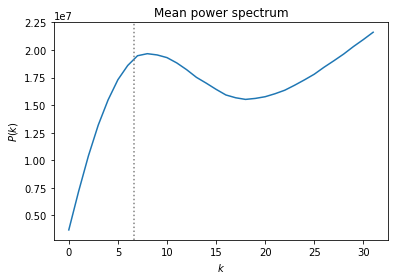

In [30]:
plt.plot(np.mean(x_pspec, axis=0))
plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)  # Scale of the PSF

plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title("Mean power spectrum")

Text(0.5, 1.0, 'Mean histogram')

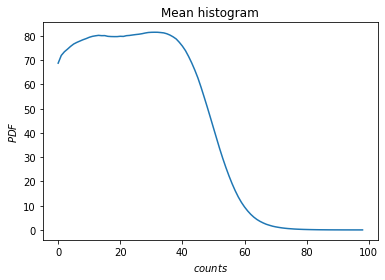

In [31]:
plt.plot(np.mean(x_hist, axis=0))

plt.xlabel("$counts$")
plt.ylabel("$PDF$")
plt.title("Mean histogram")

## Mutual information

$$\mathrm{MI}(X ; Y)=D_{\mathrm{KL}}\left(P_{(X, Y)} \| P_{X} \otimes P_{Y}\right)$$

$$\mathrm{MI}(X ; Y)=\int_{\mathcal{Y}} \int_{\mathcal{X}} p_{(X, Y)}(x, y) \log \left(\frac{p_{(X, Y)}(x, y)}{p_{X}(x) p_{Y}(y)}\right) d x d y$$

In [32]:
def calc_MI(X, Y, bins):
    """ Compute mutual information with density estimation by binning
    """
    c_XY = np.histogram2d(X, Y, bins)[0]
    c_X = np.histogram(X, bins)[0]
    c_Y = np.histogram(Y, bins)[0]

    H_X = shannon_entropy(c_X)
    H_Y = shannon_entropy(c_Y)
    H_XY = shannon_entropy(c_XY)

    MI = H_X + H_Y - H_XY
    return MI

def shannon_entropy(c):
    """ Shannon entropy
    """
    c_normalized = c / float(np.sum(c))
    c_normalized = c_normalized[np.nonzero(c_normalized)]
    H = -sum(c_normalized* np.log2(c_normalized))  
    return H

Compute the "true" MI between parameters of interest and the power spectrum.

Text(0.5, 1.0, 'Ground truth mutual information')

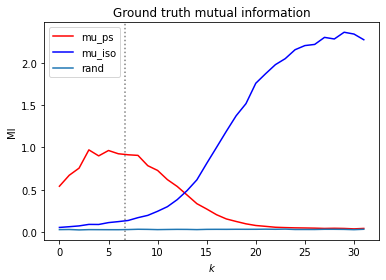

In [33]:
n_bins = 32

MI = []
for i in range(len(x_pspec[0, :])):
    MI.append(calc_MI(mu_ps, x_pspec[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_pspec[0, :])):
    MI.append(calc_MI(x_pspec[:, i], mu_iso, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

# Uncorrelate MI, as a test baseline

MI = []
for i in range(len(x_pspec[0, :])):
    MI.append(calc_MI(x_pspec[:, i], np.random.uniform(0, 3, size=x_pspec[:, i].shape), n_bins))
    
plt.plot(MI, label="rand")

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

plt.title("Ground truth mutual information")

Text(0.5, 1.0, 'Ground truth mutual information')

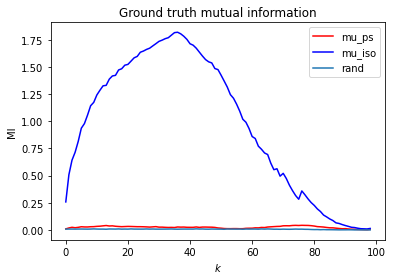

In [34]:
n_bins = 16

MI = []
for i in range(len(x_hist[0, :])):
    MI.append(calc_MI(mu_ps, x_hist[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_hist[0, :])):
    MI.append(calc_MI(x_hist[:, i], mu_iso, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

# Uncorrelate MI, as a test baseline

MI = []
for i in range(len(x_hist[0, :])):
    MI.append(calc_MI(x_hist[:, i], np.random.uniform(0, 3, size=x_hist[:, i].shape), n_bins))
    
plt.plot(MI, label="rand")

plt.legend()

# plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

plt.title("Ground truth mutual information")

## What scales is a ResNet using?

Use a CNN, specifically a ResNet, to predict the parameters of interest and compute their MI with the power spectrum to understand which scales the network is leveraging.

In [35]:
import sys
sys.path.append("../")
from models.resnet import ResNetEstimator

In [36]:
import torch
import torch.nn as nn

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import MLFlowLogger

from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

### Define and train CNN model

Define our model---a simple regression task.

In [37]:
class ResNetRegressor(pl.LightningModule):
    def __init__(self, n_out=2):
        super().__init__()
        
        self.save_hyperparameters()
        
        self.resnet = ResNetEstimator(cfg=18, n_out=n_out, log_input=False)
        self.loss = nn.MSELoss()
        
    def forward(self, x):
        x = self.resnet(x)
        return x
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=3e-4, weight_decay=1e-5)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('train_loss', loss.mean(), on_epoch=True)
                
        return loss.mean()
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('val_loss', loss.mean(), on_epoch=True)
        return loss.mean()

In [38]:
pl.utilities.seed.seed_everything(seed=np.random.randint(638))  # Set universal seed

Global seed set to 536


536

Create training dataloader

In [39]:
val_fraction = 0.1
n_samples_val = int(val_fraction * len(x))

y = torch.Tensor(np.array([mu_ps, mu_iso])).T

# Normalize inputs
y_std = y.std(axis=0)
y_mean = y.mean(axis=0)
y = (y - y_mean) / y_std

x = torch.Tensor(x)

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=16, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=16, shuffle=False)

/tmp/ipykernel_85608/993514369.py:11: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  ../torch/csrc/utils/tensor_new.cpp:201.)
  x = torch.Tensor(x)
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Instantiate and train model. Note GPU option turned on by default.

In [40]:
model = ResNetRegressor()

In [41]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
trainer = pl.Trainer(max_epochs=10, gpus=1, gradient_clip_val=0.2, callbacks=[checkpoint_callback])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.load_from_checkpoint(checkpoint_callback.best_model_path);  # Load best epoch by validation loss

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Set SLURM handle signals.

  | Name   | Type            | Params
-------------------------------------------
0 | resnet | ResNetEstimator | 12.2 M
1 | loss   | MSELoss         | 0     
-------------------------------------------
12.2 M    Trainable params
0         Non-trainable params
12.2 M    Total params
48.900    Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Global seed set to 536


Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

### Test trained model

In [42]:
simulations_test = [simulate() for _ in range(20000)]
x_test = list(map(itemgetter(2), simulations_test))
mu_ps_test = list(map(itemgetter(0), simulations_test))
mu_iso_test = list(map(itemgetter(1), simulations_test))
x_pspec_test = np.array([power_spectrum(x_i) for x_i in x_test])
x_hist_test = np.array([counts_histogram(x_i) for x_i in x_test])

In [43]:
# Normalize
y_test =  torch.Tensor(np.array([mu_ps_test, mu_iso_test])).T
y_test = (y_test - y_mean) / y_std

x_test = torch.Tensor(x_test)

In [44]:
dataset_test = TensorDataset(x_test, y_test)
test_loader = DataLoader(dataset_test, batch_size=256, num_workers=1, shuffle=False)

In [45]:
mu_ps_test, mu_iso_test = y_test.detach().numpy().T

In [46]:
model.to('cuda')

mu_pred = []
for batch in tqdm(test_loader):
    with torch.no_grad():
        x_b, y_b = batch
        mu_pred.append(model(x_b.to('cuda')).cpu())
    del x_b

  0%|          | 0/79 [00:00<?, ?it/s]

In [47]:
mu_ps_pred, mu_iso_pred = torch.cat(mu_pred).detach().numpy().T

In [53]:
H = mine.optimize(y_test, y_test, iters=2000, batch_size=512)

  0%|          | 0/2000 [00:00<?, ?it/s]

In [65]:
y_pred = torch.cat(mu_pred)
MI = mine.optimize(y_test, y_pred, iters=2000, batch_size=512)

  0%|          | 0/2000 [00:00<?, ?it/s]

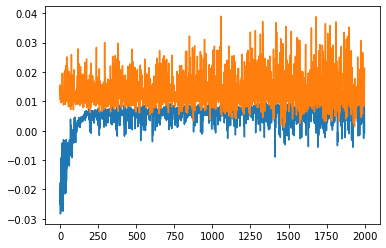

In [66]:
plt.plot(MI)
plt.plot(H)

In [70]:
np.mean(np.array(MI)[-500:]) / np.mean(np.array(H)[-500:])

0.4616165659478019

### Integrated gradients

$$\text {IntegratedGrads}_{i}(x)::=\left(x_{i}-x_{i}^{\prime}\right) \times \int_{\alpha=0}^{1} \frac{\partial F\left(x^{\prime}+\alpha \times\left(x-x^{\prime}\right)\right)}{\partial x_{i}} d \alpha$$

In [212]:
from captum.attr import IntegratedGradients

In [213]:
ig = IntegratedGradients(model)

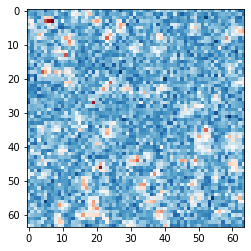

In [230]:
i_samp = 10086
plt.imshow(x_test[i_samp].detach().numpy(), cmap='RdBu_r')

tensor([1.5406], device='cuda:0', dtype=torch.float64)
tensor([0.1143], device='cuda:0', dtype=torch.float64)


Text(0.5, 1.0, 'Original map')

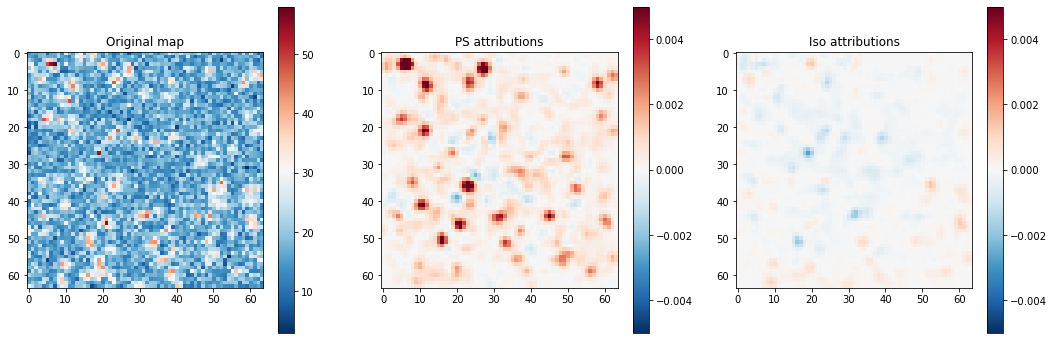

In [231]:
fig, ax = plt.subplots(figsize=(18,6), ncols=3)

titles = ["PS attributions", "Iso attributions"]

for i in range(2):
    
    baseline = (torch.mean(x_test[i_samp]) * torch.ones((1,64,64))).to('cuda')
#     baseline = torch.rand((1,64,64)).to('cuda')
    
    attributions, approximation_error = ig.attribute(x_test[i_samp].unsqueeze(0).to('cuda'),
                                        target=i,
                                        baselines=baseline,
                                        n_steps=1000,
                                        return_convergence_delta=True)
    
    attr = ax[i + 1].imshow(convolve(attributions[0].cpu().detach().numpy(), kernel), cmap='RdBu_r', vmin=-0.005, vmax=0.005,)
    fig.colorbar(attr, ax=ax[i + 1])
    ax[i + 1].set_title(titles[i])

    print(approximation_error)
    
map = ax[0].imshow(x_test[i_samp].detach().numpy(), cmap='RdBu_r')
fig.colorbar(map, ax=ax[0])
ax[0].set_title("Original map")

### Predicted vs true

Text(0, 0.5, '$\\mu_{ps, pred}$')

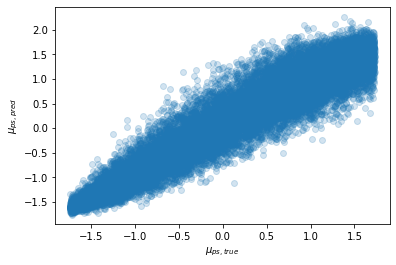

In [38]:
plt.scatter(mu_ps_test, mu_ps_pred, alpha=0.2)
plt.xlabel(r"$\mu_{ps, true}$")
plt.ylabel(r"$\mu_{ps, pred}$")

Text(0, 0.5, '$\\mu_{iso, pred}$')

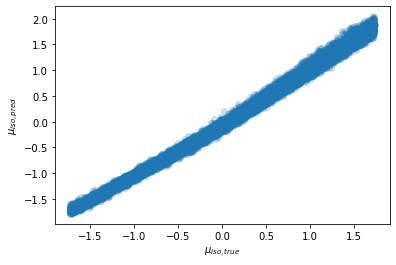

In [39]:
plt.scatter(mu_iso_test, mu_iso_pred, alpha=0.2)
plt.xlabel(r"$\mu_{iso, true}$")
plt.ylabel(r"$\mu_{iso, pred}$")

### Compute MI of prediction

Text(0, 0.5, 'MI')

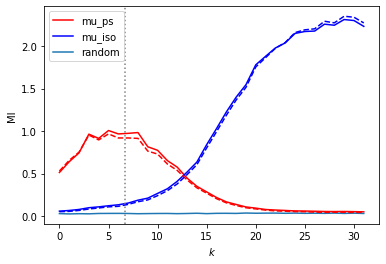

In [40]:
n_bins = 32

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_pred, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], np.random.uniform(0, 3, size=x_pspec_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_test, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

Text(0, 0.5, 'MI')

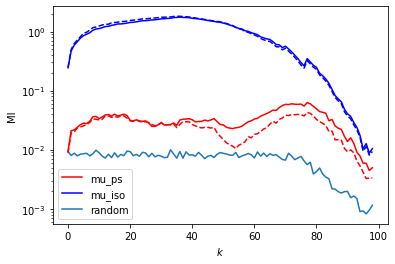

In [46]:
n_bins = 16

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(mu_ps_pred, x_hist_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(x_hist_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(x_hist_test[:, i], np.random.uniform(0, 3, size=x_hist_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(mu_ps_test, x_hist_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(x_hist_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

# plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.yscale("log")

plt.xlabel("$k$")
plt.ylabel("MI")

The CNN seems to be accurately leveraging various scales to predict the two parameters.

## What scales is a PCA decomposition using?

Perform a PCA decomposition and train it with a simple MLP.

In [71]:
from sklearn.decomposition import PCA, IncrementalPCA

Compute PCA of training data

In [72]:
pca = PCA(n_components=64)

x_flattened = x.reshape(-1, n_t * n_t)
x_pca = pca.fit_transform(x_flattened)

x_pca_mean = x_pca.mean(axis=0)
x_pca_std = x_pca.std(axis=0)

x_pca = (x_pca - x_pca_mean) / x_pca_std

In [73]:
# plt.plot(np.cumsum(pca.explained_variance_ratio_))
# plt.xlabel("n_components")
# plt.ylabel("% variance explained")

### Define and train model

In [74]:
## A simple MLP

def build_mlp(input_dim, hidden_dim, output_dim, layers, activation='relu'):
    """Create a MLP from the configurations
    """
    
    activation = nn.ReLU

    seq = [nn.Linear(input_dim, hidden_dim), activation()]
    for _ in range(layers):
        seq += [nn.Linear(hidden_dim, hidden_dim), activation()]
    seq += [nn.Linear(hidden_dim, output_dim)]

    return nn.Sequential(*seq)

In [75]:
class PCANet(pl.LightningModule):
    def __init__(self, n_out=2):
        super().__init__()
        
        self.save_hyperparameters()
        
        # Simple 4-layer MLP
        self.mlp = build_mlp(64, 128, n_out, 4, 'relu')
        self.loss = nn.MSELoss()
        
    def forward(self, x):
        x = self.mlp(x)
        return x
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-5)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('train_loss', loss.mean(), on_epoch=True)
                
        return loss.mean()
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('val_loss', loss.mean(), on_epoch=True)
        return loss.mean()

Define dataset, this time with PCA decomposition as input variable

In [76]:
pl.utilities.seed.seed_everything(seed=np.random.randint(638))  # Set universal seed

Global seed set to 112


112

In [77]:
dataset = TensorDataset(torch.Tensor(x_pca), y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=16, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=16, shuffle=False)

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Train model. Note not using GPU by default.

In [78]:
model = PCANet()

checkpoint_callback = ModelCheckpoint(monitor="val_loss")
trainer = pl.Trainer(max_epochs=10, gpus=0, gradient_clip_val=0.2, callbacks=[checkpoint_callback])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/pytorch_lightning/trainer/trainer.py:1303: UserWarning: GPU available but not used. Set the gpus flag in your trainer `Trainer(gpus=1)` or script `--gpus=1`.
  rank_zero_warn(
Set SLURM handle signals.

  | Name | Type       | Params
------------------------------------
0 | mlp  | Sequential | 74.6 K
1 | loss | MSELoss    | 0     
------------------------------------
74.6 K    Trainable params
0         Non-trainable params
74.6 K    Total params
0.299     Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Global seed set to 112


Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [79]:
x_test_flattened = x_test.reshape(-1, n_t * n_t)
x_test_pca = pca.fit_transform(x_test_flattened)
x_test_pca = (x_test_pca - x_pca_mean) / x_pca_std

In [80]:
dataset_test = TensorDataset(torch.Tensor(x_test_pca), y_test)
test_loader = DataLoader(dataset_test, batch_size=256, num_workers=1, shuffle=False)

In [81]:
mu_ps_test, mu_iso_test = y_test.detach().numpy().T

In [82]:
mu_pred = []
for batch in tqdm(test_loader):
    with torch.no_grad():
        x_b, y_b = batch
        mu_pred.append(model(x_b))
    del x_b

  0%|          | 0/79 [00:00<?, ?it/s]

In [83]:
y_pred = torch.cat(mu_pred)
MI = mine.optimize(y_test, y_pred, iters=2000, batch_size=512)

  0%|          | 0/2000 [00:00<?, ?it/s]

In [84]:
np.mean(np.array(MI)[-500:]) / np.mean(np.array(H)[-500:])

0.31200508906096924

In [59]:
mu_ps_pred, mu_iso_pred = torch.cat(mu_pred).detach().numpy().T

Text(0, 0.5, '$\\mu_{ps, pred}$')

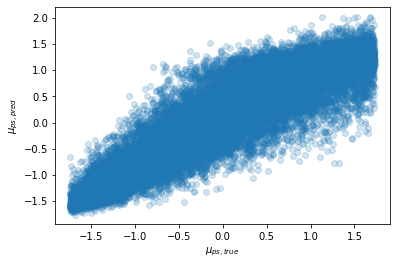

In [60]:
plt.scatter(mu_ps_test, mu_ps_pred, alpha=0.2)
plt.xlabel(r"$\mu_{ps, true}$")
plt.ylabel(r"$\mu_{ps, pred}$")

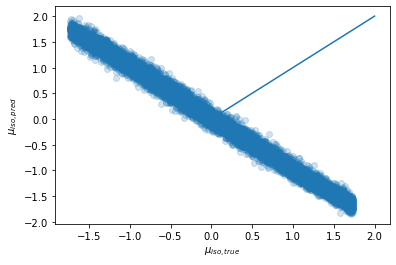

In [61]:
plt.scatter(mu_iso_test, -mu_iso_pred, alpha=0.2)
plt.xlabel(r"$\mu_{iso, true}$")
plt.ylabel(r"$\mu_{iso, pred}$")

plt.plot([0,2],[0,2])

Text(0, 0.5, 'MI')

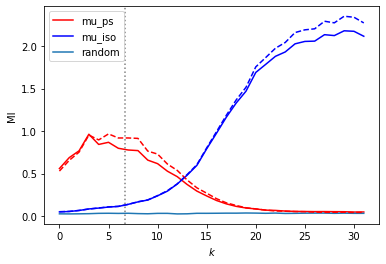

In [63]:
n_bins = 32

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_pred, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], np.random.uniform(0, 3, size=x_pspec_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_test, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

Text(0, 0.5, 'MI')

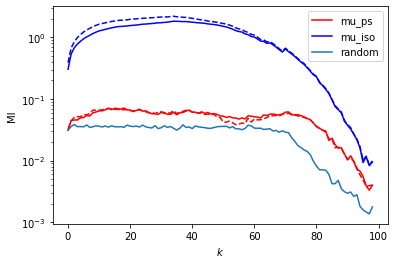

In [65]:
n_bins = 32

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(mu_ps_pred, x_hist_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(x_hist_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(x_hist_test[:, i], np.random.uniform(0, 3, size=x_hist_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(mu_ps_test, x_hist_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_hist_test[0, :])):
    MI.append(calc_MI(x_hist_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

# plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.yscale("log")

plt.xlabel("$k$")
plt.ylabel("MI")

## $P(k)$-guided learning

Add an additional loss term to constrain learning. Everything below is highly experimental! The current mutual information calculation cannot be used since I could not find a differentiable version of the histogram for PyTorch; therefore using distance correlation.

In [332]:
from models.disco import distance_corr

In [350]:
class PCANetMI(pl.LightningModule):
    def __init__(self, n_out=2):
        super().__init__()
        
        self.save_hyperparameters()
        
        self.mlp = build_mlp(64, 128, n_out, 4, 'relu')
        self.mse_loss = nn.MSELoss()
                
        self.loss_mi_list = []
        
    def forward(self, x):
        x = self.mlp(x)
        return x
    
    def loss(self, x_f, y, out):
        
        loss = self.mse_loss(y, out)
         
        loss_mi = 0.
        
#         mi_true = distance_corr(x_f[:], y[:,])
#         mi_pred = distance_corr(x_f[:], out[:])
        
#         loss_mi = self.mse_loss(mi_true, mi_pred) * 1e4
        
        for i in range(32):
            
            mi_true = distance_corr(x_f[:, i].unsqueeze(1), y[:,0].unsqueeze(1))
            mi_pred = distance_corr(x_f[:, i].unsqueeze(1), out[:,0].unsqueeze(1))

            loss_mi += self.mse_loss(mi_true, mi_pred)
            
        for i in range(32):
            
            mi_true = distance_corr(x_f[:, i].unsqueeze(1), y[:,1].unsqueeze(1))
            mi_pred = distance_corr(x_f[:, i].unsqueeze(1), out[:,1].unsqueeze(1))

            loss_mi += self.mse_loss(mi_true, mi_pred)

        return loss, loss_mi
    
#     def mi(self, X, Y):
#         return calc_MI_torch(X, Y, 32)
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-5)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, x_f, y = batch
        out = self(x)     
        loss, loss_mi = self.loss(x_f, y, out)
        self.log('train_loss', loss_mi, on_epoch=True)
        self.loss_mi_list.append(loss_mi)
        return loss_mi
    
    def validation_step(self, batch, batch_idx):
        x, x_f, y = batch
        out = self(x)     
        loss, loss_mi = self.loss(x_f, y, out)
        self.log('val_loss', loss, on_epoch=True)
        return loss

In [351]:
dataset = TensorDataset(torch.Tensor(x_pca), torch.Tensor(x_pspec), y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=256, num_workers=0, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=256, num_workers=0, shuffle=False)

In [352]:
pl.utilities.seed.seed_everything(seed=np.random.randint(638))  # Set universal seed

model = PCANetMI()

Global seed set to 25


In [353]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
trainer = pl.Trainer(max_epochs=10, gpus=0, gradient_clip_val=0.2, callbacks=[checkpoint_callback])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
# model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
Set SLURM handle signals.

  | Name     | Type       | Params
----------------------------------------
0 | mlp      | Sequential | 74.6 K
1 | mse_loss | MSELoss    | 0     
----------------------------------------
74.6 K    Trainable params
0         Non-trainable params
74.6 K    Total params
0.299     Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Global seed set to 25


Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

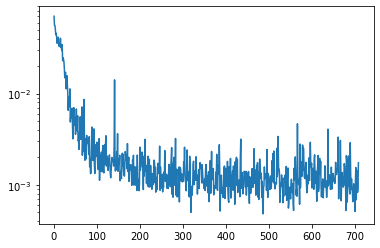

In [354]:
plt.plot([loss.detach().numpy() for loss in model.loss_mi_list])
plt.yscale("log")

In [355]:
dataset_test = TensorDataset(torch.Tensor(x_test_pca), torch.Tensor(x_pspec_test), y_test)
test_loader = DataLoader(dataset_test, batch_size=256, num_workers=0, shuffle=False)

In [356]:
mu_pred = []
for batch in tqdm(test_loader):
    with torch.no_grad():
        x_b, x_f, y_b = batch
        mu_pred.append(model(x_b))
    del x_b

  0%|          | 0/79 [00:00<?, ?it/s]

In [357]:
mu_ps_pred, mu_iso_pred = torch.cat(mu_pred).detach().numpy().T

Text(0, 0.5, '$\\mu_{iso, pred}$')

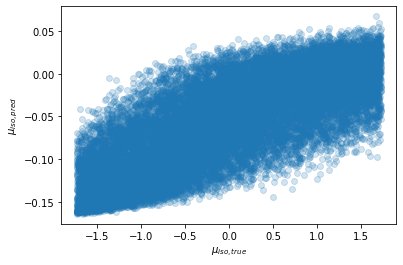

In [358]:
plt.scatter(mu_ps_test, mu_ps_pred, alpha=0.2)
plt.xlabel(r"$\mu_{iso, true}$")
plt.ylabel(r"$\mu_{iso, pred}$")

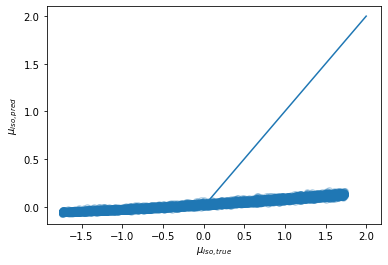

In [359]:
plt.scatter(mu_iso_test, -mu_iso_pred, alpha=0.2)
plt.xlabel(r"$\mu_{iso, true}$")
plt.ylabel(r"$\mu_{iso, pred}$")

plt.plot([0,2],[0,2])

Text(0, 0.5, 'MI')

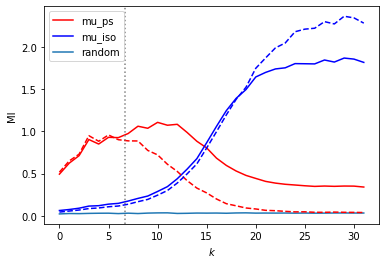

In [361]:
n_bins = 32

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_pred, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], np.random.uniform(0, 3, size=x_pspec_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(mu_ps_test, x_pspec_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_pspec_test[0, :])):
    MI.append(calc_MI(x_pspec_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

In [67]:
from models.histogramdd import histogramdd
import torchist

In [68]:
calc_MI(mu_iso_pred, x_f_test[:, i], 32)

2.4112492775033942

In [73]:
calc_MI_torch(torch.Tensor(mu_iso_pred), torch.Tensor(x_f_test[:, i]),  32)

tensor(2.4112)

In [146]:
from torch.autograd import grad
x = autodiff_test(torch.Tensor(mu_iso_pred).to('cuda'))
grad(x, mu)

In [70]:
def calc_MI_torch(X, Y, bins=32):

    c_XY = torchist.histogramdd(torch.vstack([X, Y]).T, 32)
    c_X = torchist.histogram(X,bins)
    c_Y = torchist.histogram(Y,bins)
        
    H_X = shannon_entropy_torch(c_X)
    H_Y = shannon_entropy_torch(c_Y)
    H_XY = shannon_entropy_torch(c_XY)
    
    MI = H_X + H_Y - H_XY
    return MI

def shannon_entropy_torch(c):
    c_normalized = c / torch.sum(c)
    c_normalized = c_normalized[torch.nonzero(c_normalized, as_tuple=True)]
    H = -torch.sum(c_normalized * torch.log2(c_normalized))  
    return H

In [3]:
from kornia.enhance import histogram2d

In [21]:
histogram2d(torch.Tensor(mu_z_n).unsqueeze(0), torch.Tensor(x_f[:, 0]).unsqueeze(0), torch.linspace(0, , 0)

SyntaxError: invalid syntax (1372670118.py, line 2)